# Week 5 - Function 7 ((34DP, 6D))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [1]:
import numpy as np

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
from sklearn.svm import SVC, SVR
from scipy.stats.qmc import LatinHypercube

from utils.plotting_utils import (
    plot_6D_blackbox_analysis,
    plot_output_outliers,
    plot_bar_diff,
    plot_nd_mean_uncertainty_slice,
    plot_nd_svm_analysis_slice,
    plot_nd_acquisition_comparison_slice
)

# Plan
We now have ((34, 6)) — 34 data points, 6 dimensions, from `./data/week_5/function_7/`.

**Architecture**: Dual-GP ensemble (QT + log10) with SVM-constrained UCB.

**Key decisions** (carried forward):
- QuantileTransformer + log10 shift: outlier spikes (y ∈ [0.003, 1.61])
- SVM C=1 soft margin, median threshold, fail-safe at <5% coverage
- Both GPs identify x3 as noise (ls=100, 0.1% importance in both)

**Week 5 fixes:**
- **x3 noise drop**: LHS candidates generated in 5D active subspace [x1,x2,x4,x5,x6]; x3 fixed at training mean — same pattern as Fn8 which succeeded in week 5
- kappa=4.08 (budget-aware: week 5/13); 50K LHS candidates in 5D active space

**Steps:** Load data → Preprocessing → GP models (full 6D ARD, identifies x3 as noise) → SVM → Acquisition (5D active subspace) → Report

# 1. Load data

In [2]:
X_train_raw = np.load(r"./data/week_5/function_7/inputs.npy")
y_train_raw = np.load(r"./data/week_5/function_7/outputs.npy")
print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.2e}, {y_train_raw.max():.2e}]")

Shape: X=(34, 6), y=(34,)
X range: [0.0036, 0.9987]
y range: [2.70e-03, 1.61e+00]


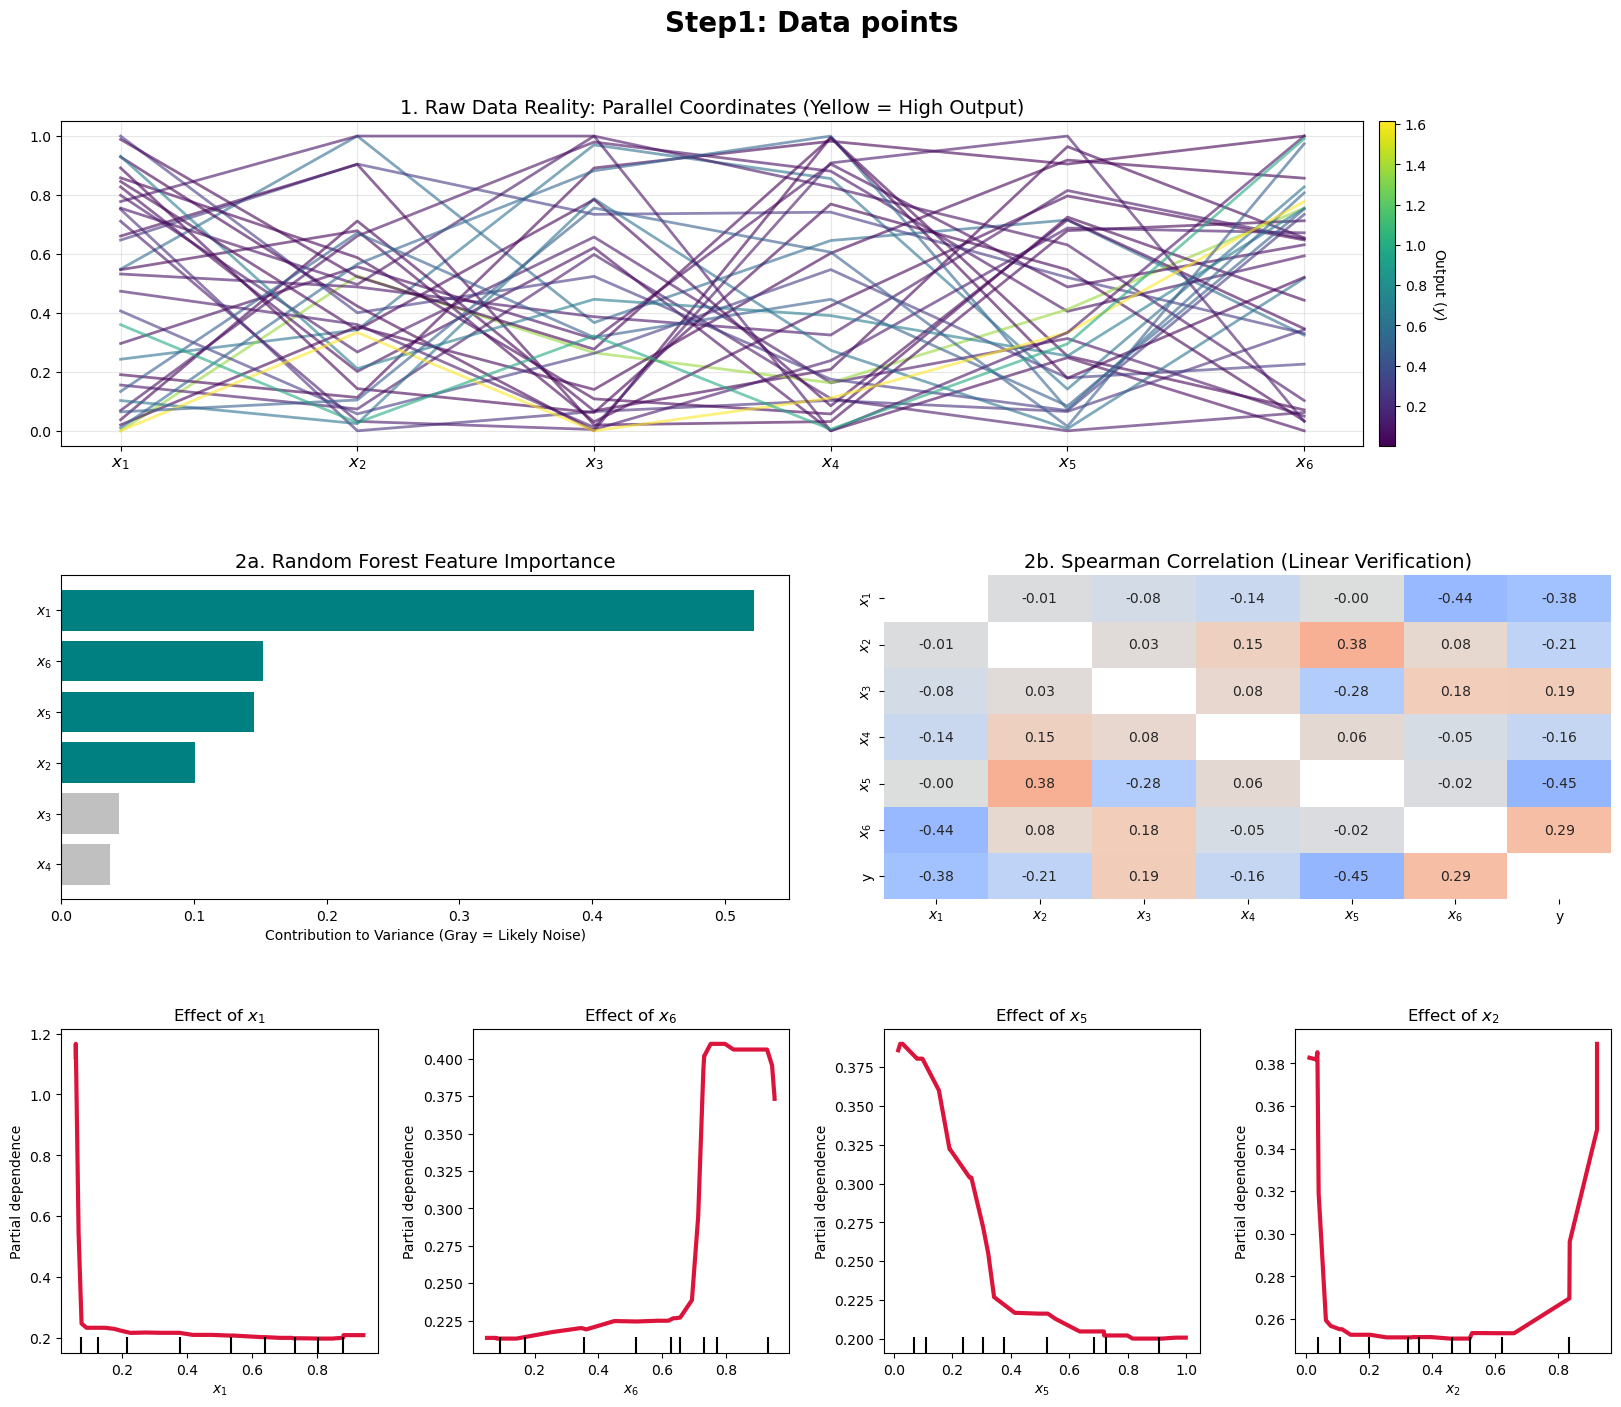

In [3]:
plot_6D_blackbox_analysis(X_train_raw, y_train_raw, "Step1: Data points", f"""
DATA SUMMARY
{'='*30}
Points: {len(X_train_raw)}
Input shape: {X_train_raw.shape}
Output shape: {y_train_raw.shape}

CURRENT BEST
{'='*30}
Current best: {np.max(y_train_raw)}
At input: {X_train_raw[np.argmax(y_train_raw)]}
""")

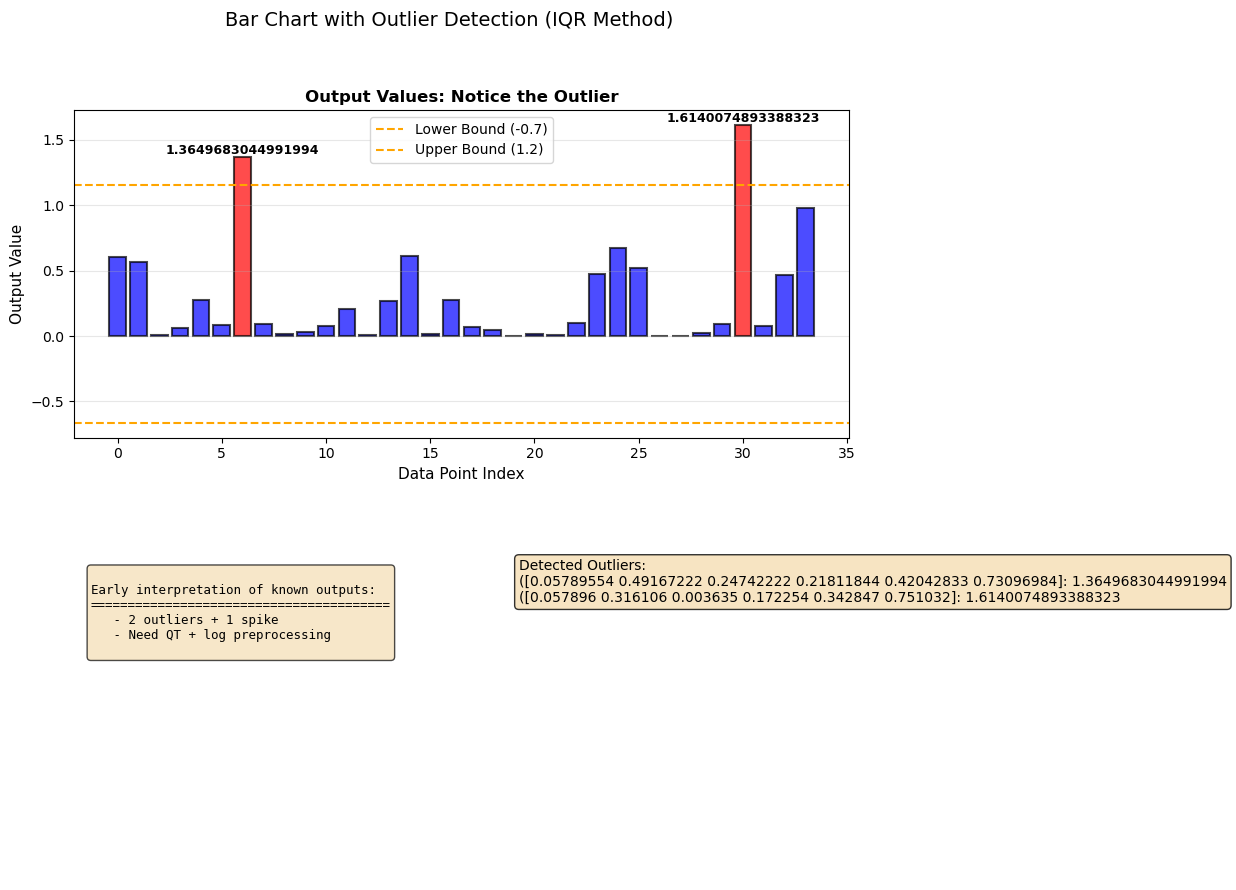

In [4]:
plot_output_outliers(X_train_raw, y_train_raw, "Bar Chart with Outlier Detection (IQR Method)", f"""
Early interpretation of known outputs:
{'='*40}
   - 2 outliers + 1 spike
   - Need QT + log preprocessing
""")

# 2. Preprocessing

Output has outlier spikes. Using QuantileTransformer + log10 shift.

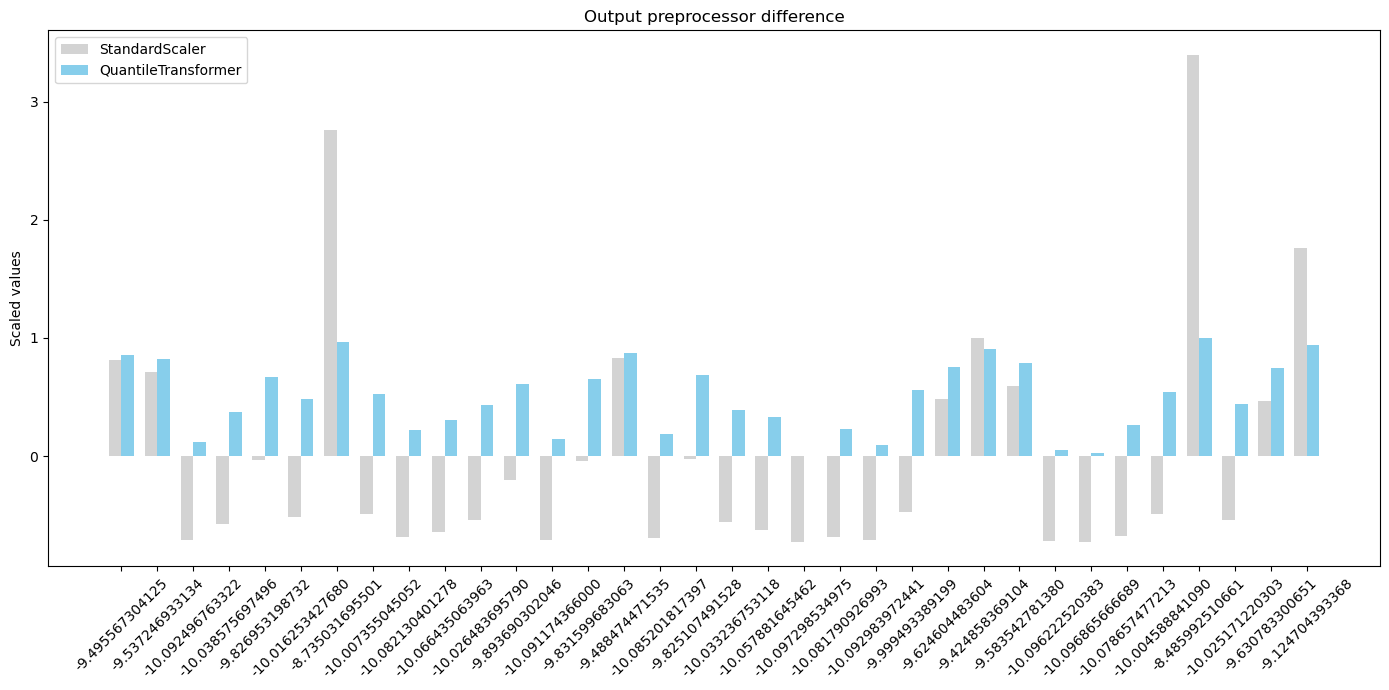

Total points: 34
QT range: [0.0, 1.0]

Log shift constant: 1.00
All 34 points included in log space
log10(y_shifted) range: [0.0023, 0.4178]


In [5]:
scaler_X = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train_raw)

from sklearn.preprocessing import StandardScaler
scaler_ss = StandardScaler()
y_ss = scaler_ss.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

scaler_qt = QuantileTransformer(n_quantiles=len(y_train_raw)-1, output_distribution='uniform')
y_qt = scaler_qt.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

plot_bar_diff(y_train_raw, y_ss, y_qt, 'StandardScaler', 'QuantileTransformer',
              'Scaled values', 'Output preprocessor difference')

print(f"Total points: {len(X_train)}")
print(f"QT range: [{y_qt.min():.1f}, {y_qt.max():.1f}]")

# Log transform: shift by abs(min)+1 guarantees all values positive (min shifted = 1.0)
log_shift_constant = abs(y_train_raw.min()) + 1.0
y_train_raw_shifted = y_train_raw + log_shift_constant
X_train_pos = X_train              # all points (no masking needed)
y_log_pos = np.log10(y_train_raw_shifted)

print(f"\nLog shift constant: {log_shift_constant:.2f}")
print(f"All {len(y_train_raw)} points included in log space")
print(f"log10(y_shifted) range: [{y_log_pos.min():.4f}, {y_log_pos.max():.4f}]")

# 3. Build probabilistic Models (2-GP ensemble)

- **gp_qt**: GP on QuantileTransformer output (all points)
- **gp_log**: GP on log10 output (positive points)

In [6]:
n_dims = 6

gp_qt = GaussianProcessRegressor(
    kernel=ConstantKernel(0.25, (1e-3, 10)) * Matern(
        length_scale=[0.5]*n_dims, nu=2.5,
        length_scale_bounds=(0.05, 1e6)
    ),
    alpha=0.01, normalize_y=True,
    n_restarts_optimizer=30
)

gp_log = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
        length_scale=[0.5]*n_dims, nu=2.5,
        length_scale_bounds=(1e-3, 1e6)
    ),
    alpha=1e-4, normalize_y=True,
    n_restarts_optimizer=50
)

gp_qt.fit(X_train, y_qt)
gp_log.fit(X_train, y_log_pos)

print(f"GP(QT) kernel: {gp_qt.kernel_}")
print(f"GP(log) kernel: {gp_log.kernel_}")

# Feature importance from ARD length scales
for name, gp in [('GP(QT)', gp_qt), ('GP(log)', gp_log)]:
    ls = gp.kernel_.k2.length_scale
    imp = 1.0 / ls
    imp_norm = imp / imp.sum() * 100
    print(f"\n{name} length scales: {ls}")
    sorted_dims = np.argsort(ls)
    for i in sorted_dims:
        role = 'IMPORTANT' if ls[i] < 1.0 else ('moderate' if ls[i] < 5.0 else 'noise')
        print(f"  x{i+1}: ls={ls[i]:.4f}, importance={imp_norm[i]:.1f}%, {role}")

# Determine plot/slider dims from gp_qt
ls_qt = gp_qt.kernel_.k2.length_scale
sorted_dims = np.argsort(ls_qt)
most_important = sorted_dims[:2]  # plot these
least_important = sorted_dims[2:]  # 4 sliders
dim_a, dim_b = most_important[0], most_important[1]
slider_dims = least_important
print(f"\nPlotting dims: x{dim_a+1}, x{dim_b+1}")
print(f"Slider dims: {['x'+str(d+1) for d in slider_dims]}")

GP(QT) kernel: 1**2 * Matern(length_scale=[1.31, 0.565, 4.38e+05, 0.41, 0.379, 0.463], nu=2.5)
GP(log) kernel: 0.956**2 * Matern(length_scale=[1.17, 0.562, 1e+06, 0.725, 0.334, 0.457], nu=2.5)

GP(QT) length scales: [1.30798093e+00 5.65084872e-01 4.38151649e+05 4.09968898e-01
 3.79018025e-01 4.63279393e-01]
  x5: ls=0.3790, importance=27.0%, IMPORTANT
  x4: ls=0.4100, importance=25.0%, IMPORTANT
  x6: ls=0.4633, importance=22.1%, IMPORTANT
  x2: ls=0.5651, importance=18.1%, IMPORTANT
  x1: ls=1.3080, importance=7.8%, moderate
  x3: ls=438151.6493, importance=0.0%, noise

GP(log) length scales: [1.17477805e+00 5.62315138e-01 1.00000000e+06 7.24783340e-01
 3.33503961e-01 4.57347991e-01]
  x5: ls=0.3335, importance=32.6%, IMPORTANT
  x6: ls=0.4573, importance=23.8%, IMPORTANT
  x2: ls=0.5623, importance=19.3%, IMPORTANT
  x4: ls=0.7248, importance=15.0%, IMPORTANT
  x1: ls=1.1748, importance=9.3%, moderate
  x3: ls=1000000.0000, importance=0.0%, noise

Plotting dims: x5, x4
Slider dims: [

/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 1000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### GP Slices

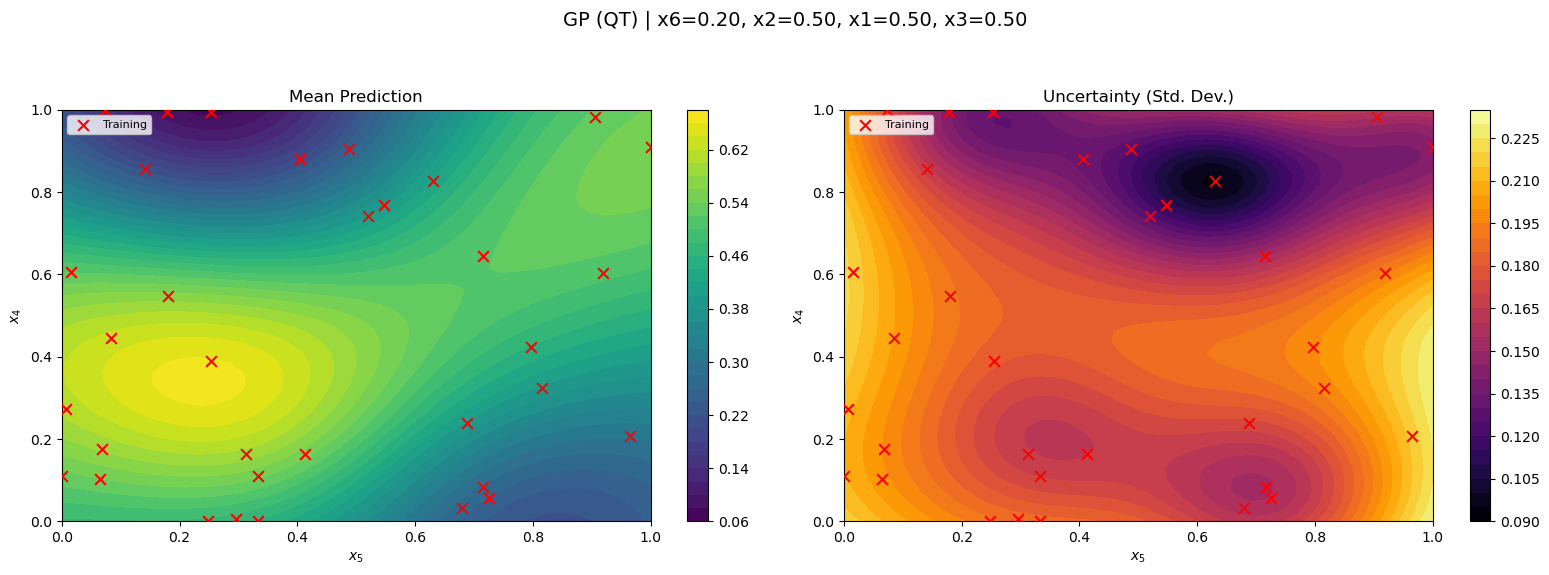

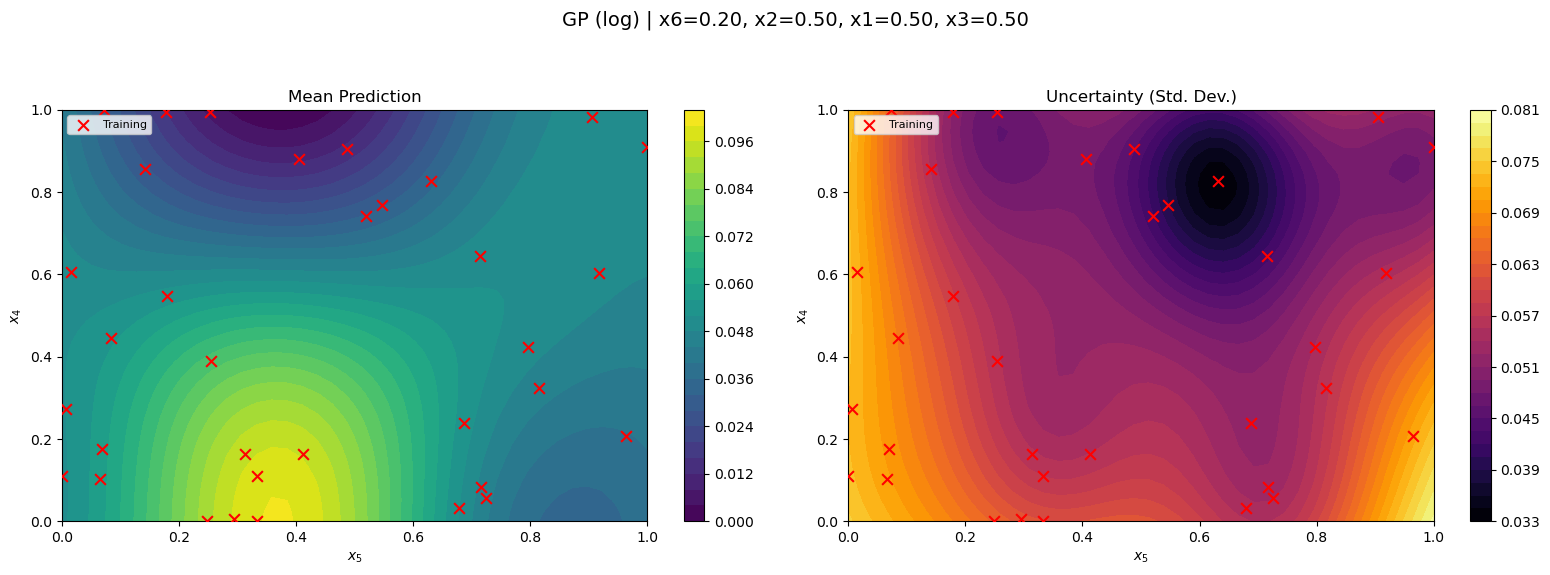

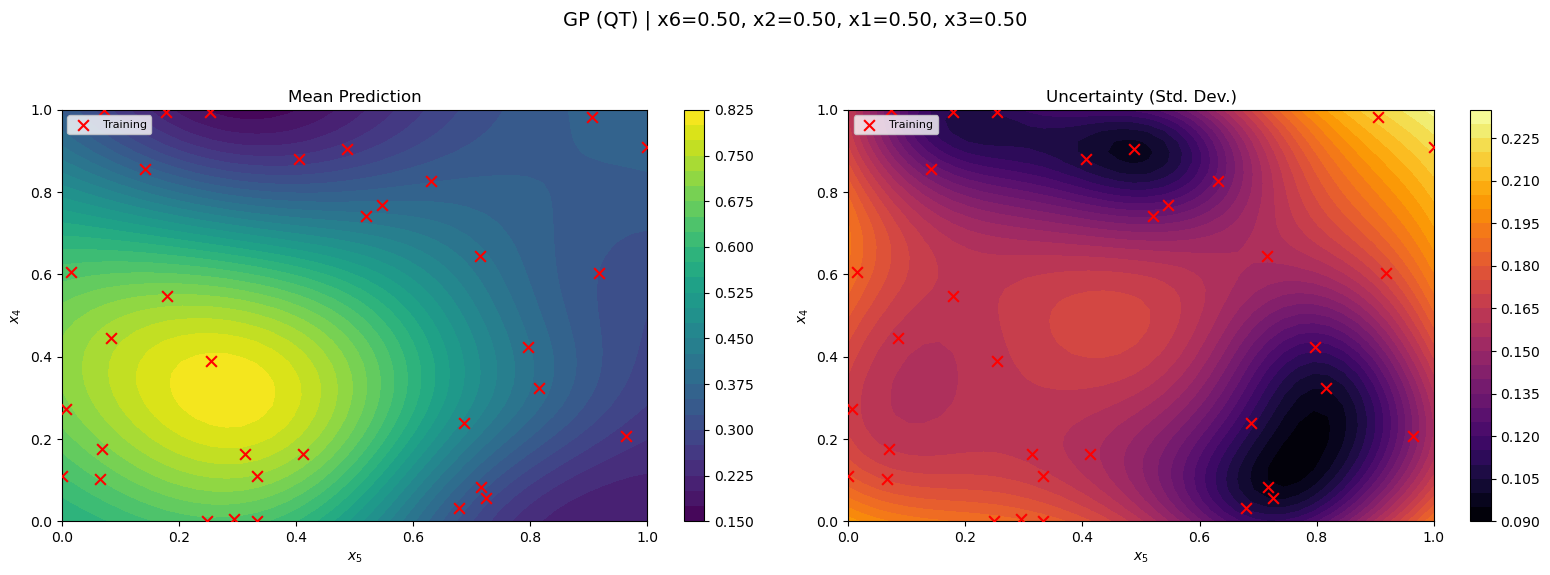

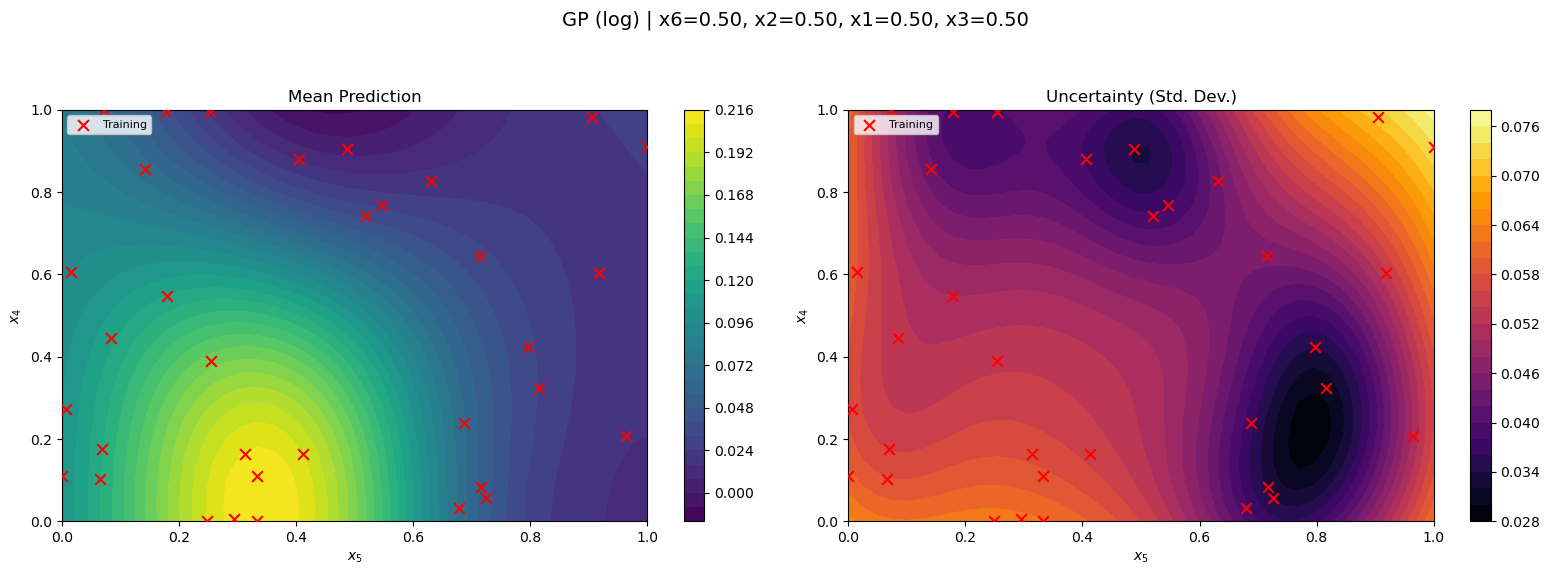

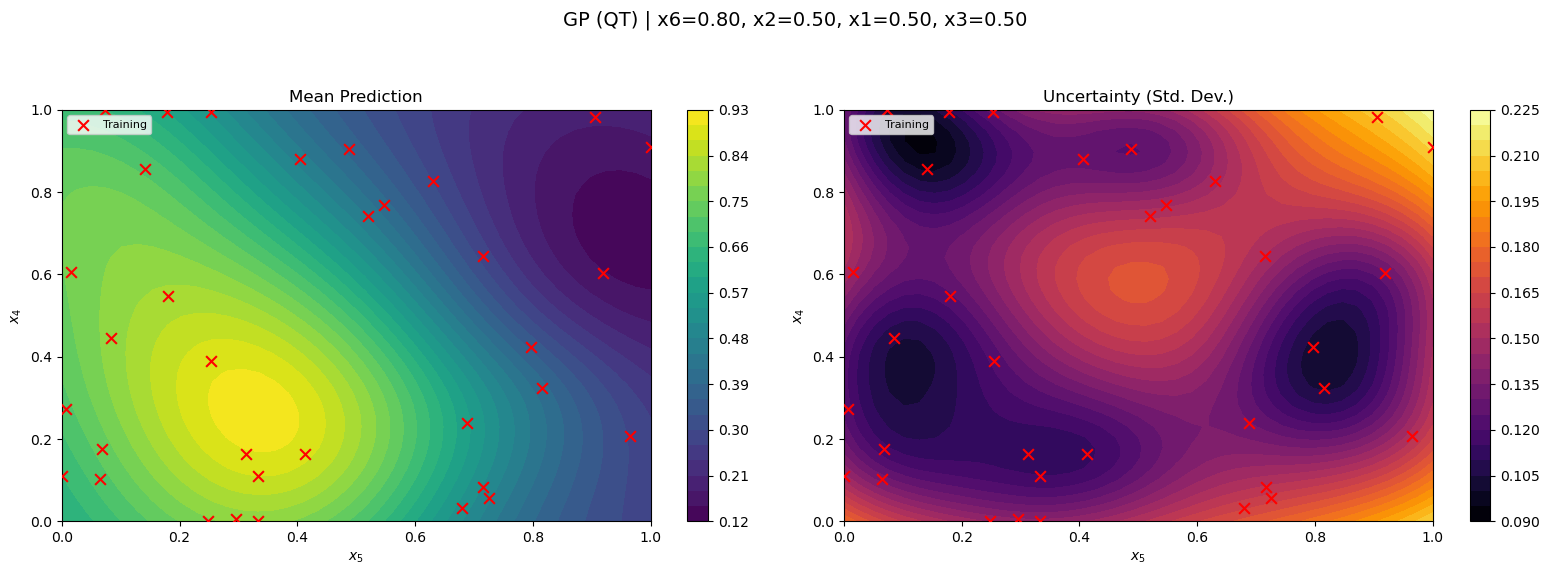

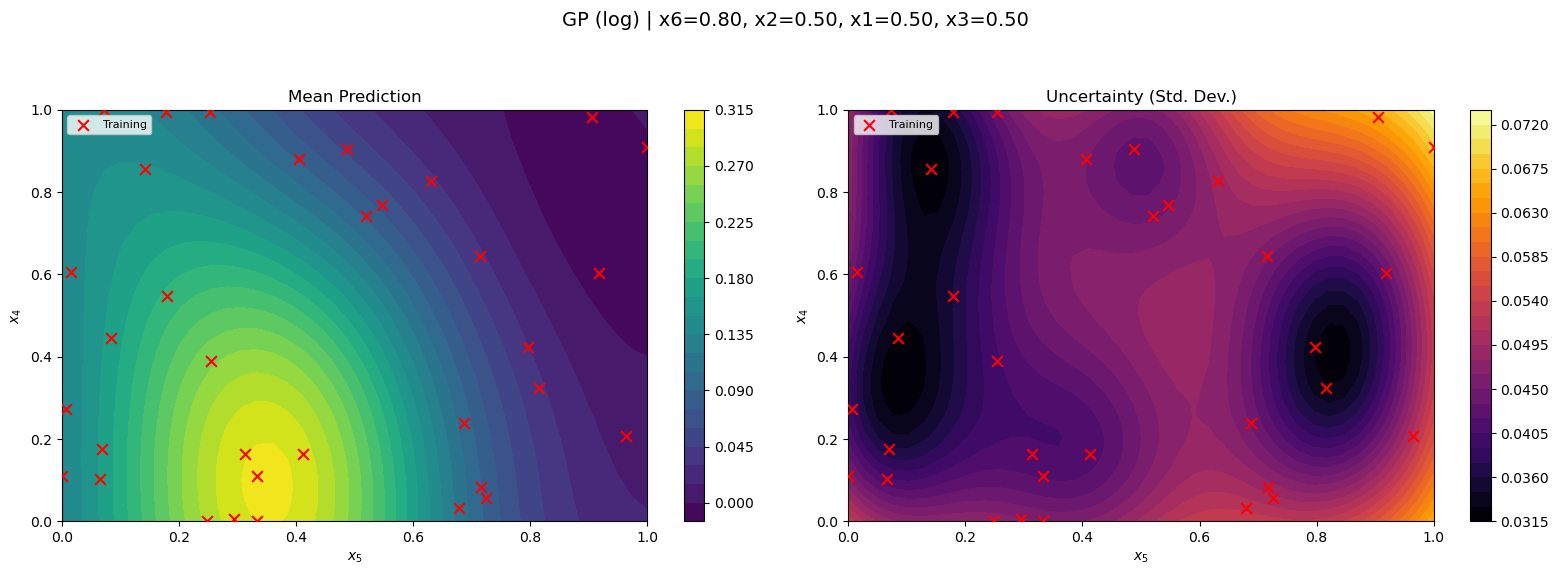

In [7]:
n_grid_2d = 40
x_plot_1 = np.linspace(0, 1, n_grid_2d)
x_plot_2 = np.linspace(0, 1, n_grid_2d)
X1_plot, X2_plot = np.meshgrid(x_plot_1, x_plot_2)

X_train_neg = np.empty((0, X_train.shape[1]))  # no excluded points (shift covers all)

def plot_gp_slices(**kwargs):
    grid_nd = np.zeros((n_grid_2d * n_grid_2d, n_dims))
    grid_nd[:, dim_a] = X1_plot.ravel()
    grid_nd[:, dim_b] = X2_plot.ravel()
    for d in slider_dims:
        grid_nd[:, d] = kwargs[f'x{d+1}']

    fixed_parts = [f'x{d+1}={kwargs[f"x{d+1}"]:.2f}' for d in slider_dims]
    fixed_info = ', '.join(fixed_parts)

    mu_qt, sigma_qt = gp_qt.predict(grid_nd, return_std=True)
    plot_nd_mean_uncertainty_slice(
        X_train, X1_plot, X2_plot,
        mu_qt.reshape(n_grid_2d, n_grid_2d),
        sigma_qt.reshape(n_grid_2d, n_grid_2d),
        dim1_idx=dim_a, dim2_idx=dim_b,
        title_prefix='GP (QT)', fixed_info=fixed_info
    )

    mu_log, sigma_log = gp_log.predict(grid_nd, return_std=True)
    plot_nd_mean_uncertainty_slice(
        X_train, X1_plot, X2_plot,
        mu_log.reshape(n_grid_2d, n_grid_2d),
        sigma_log.reshape(n_grid_2d, n_grid_2d),
        dim1_idx=dim_a, dim2_idx=dim_b,
        title_prefix='GP (log)', fixed_info=fixed_info
    )

for v in [0.2, 0.5, 0.8]:
    kws = {f'x{d+1}': (v if d == slider_dims[0] else 0.5) for d in slider_dims}
    plot_gp_slices(**kws)

# 4. SVM Analysis


=== Support Vectors: 28 / 34 training points ===
 Idx         Label        x1        x2        x3        x4        x5        x6         y_raw
   2           not    0.0908    0.6615    0.0659    0.2586    0.9635    0.6403      0.007503
   3           not    0.1189    0.6151    0.9058    0.8553    0.4136    0.5852      0.061424
   5           not    0.7649    0.2559    0.6091    0.2181    0.3229    0.0958      0.083747
   8           not    0.6423    0.8369    0.0218    0.1015    0.6831    0.6924      0.017870
   9           not    0.7899    0.1955    0.5756    0.0737    0.2590    0.0511      0.033565
  10           not    0.5285    0.4574    0.3601    0.3620    0.8169    0.6375      0.073516
  12           not    0.0757    0.3345    0.1327    0.6083    0.9184    0.8223      0.008826
  15           not    0.8171    0.5482    0.1033    0.1244    0.7282    0.4497      0.014798
  17           not    0.7263    0.4649    0.9246    0.8072    0.6354    0.1434      0.066763
  18           not  

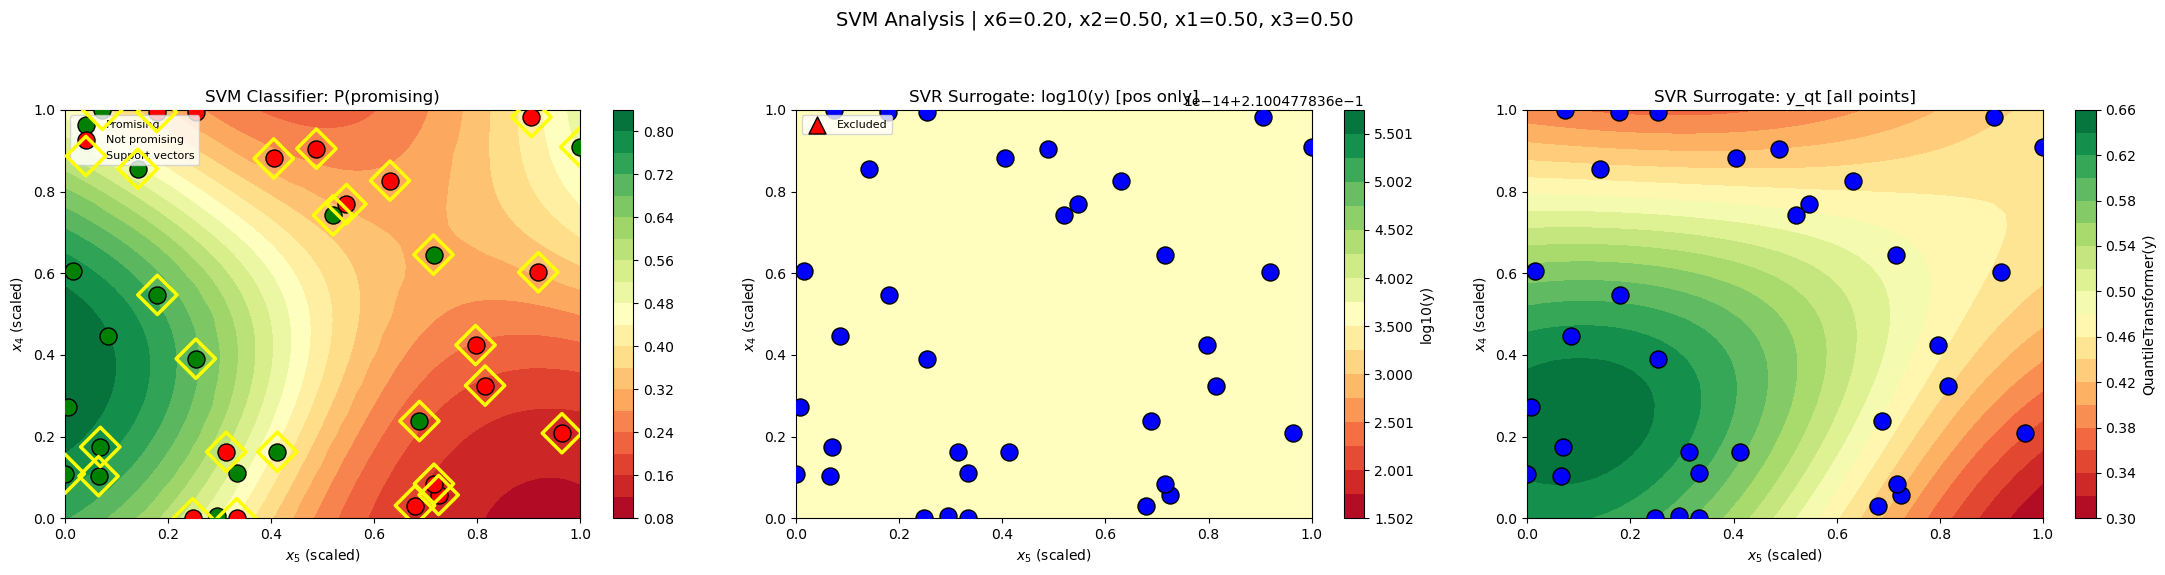

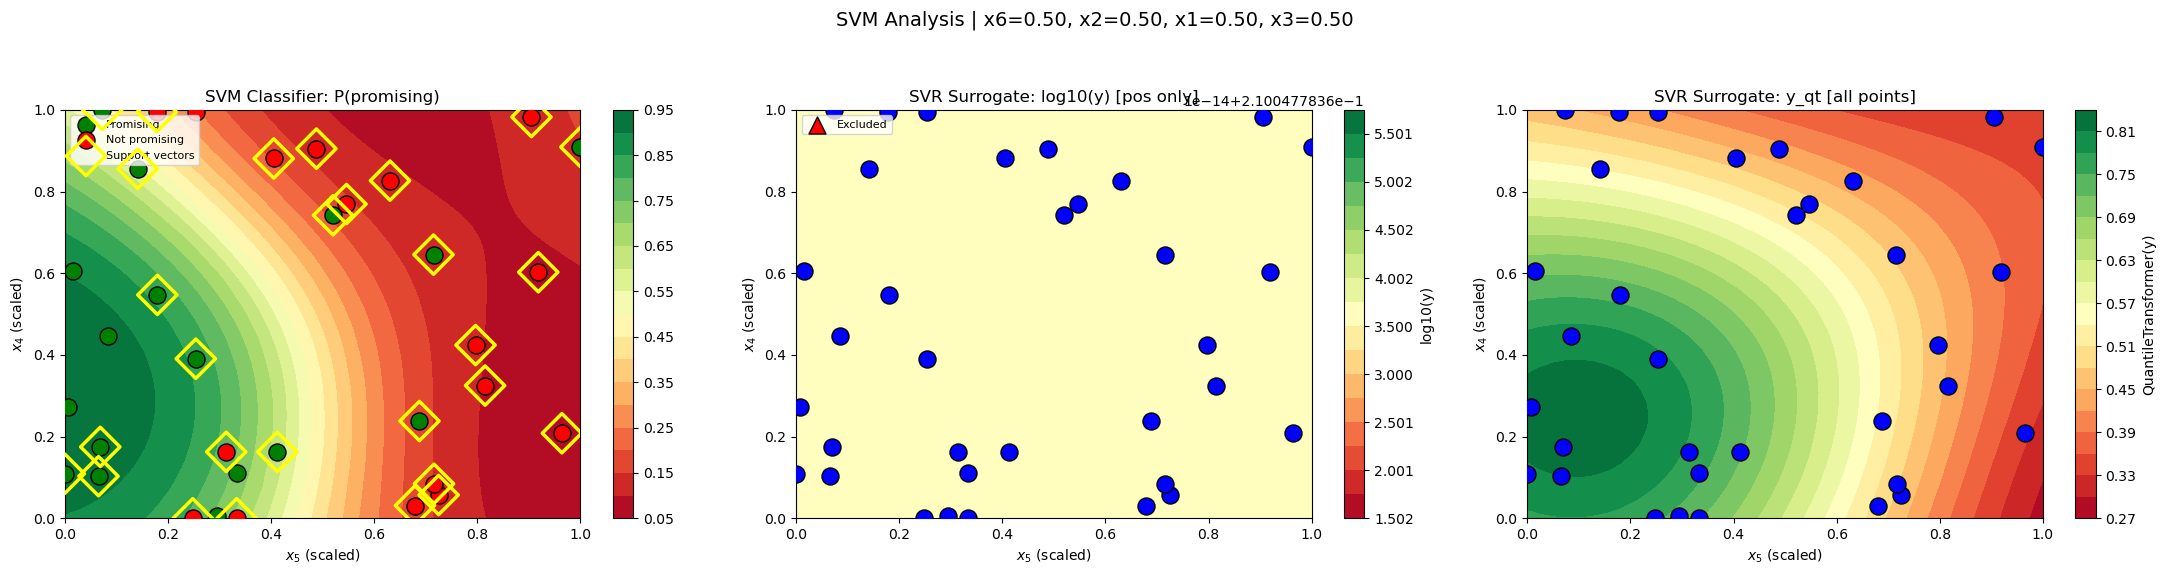

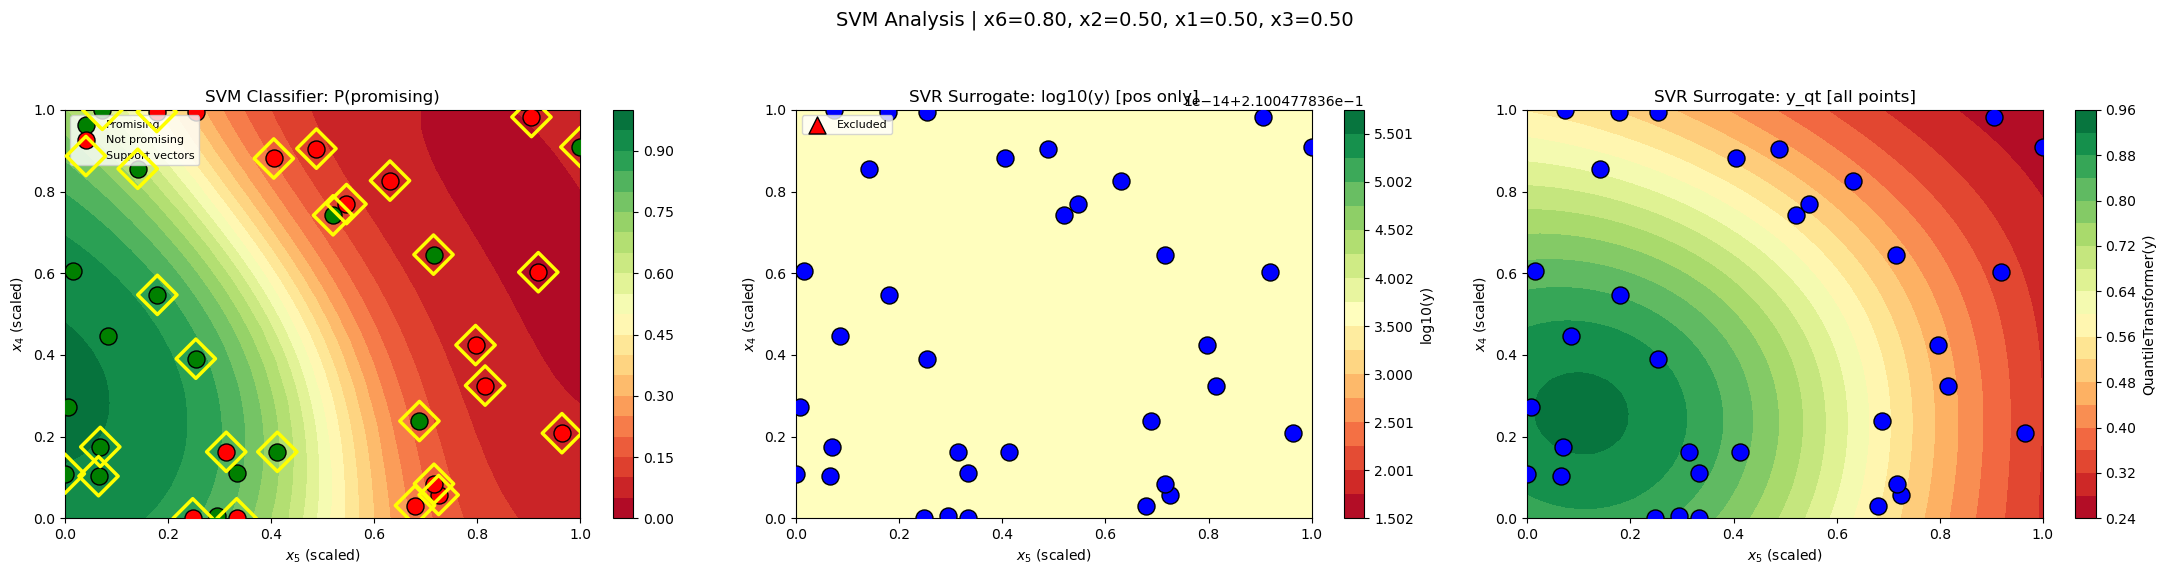

In [8]:
# SVM Classifier
# Fix B: C reduced from 10 → 1 (softer margin) to prevent decision boundary from
#        collapsing to an infinitesimally small island around the support vectors.
# gamma=2.0: between 'auto' (too broad → all SVs, flat P) and 'scale' (too local → boundary collapse).
svm_labels = (y_log_pos > np.median(y_log_pos)).astype(int)

svm_clf = SVC(kernel='rbf', C=10, gamma=2.0, probability=True)
svm_clf.fit(X_train, svm_labels)

# --- Support Vector Analysis ---
sv_indices = svm_clf.support_
support_vec_mask = np.zeros(len(X_train), dtype=bool)
support_vec_mask[sv_indices] = True

X_sv_orig = scaler_X.inverse_transform(X_train[sv_indices])
y_sv_raw  = y_train_raw[sv_indices]
sv_labels_vals = svm_labels[sv_indices]

print(f"\n=== Support Vectors: {len(sv_indices)} / {len(X_train)} training points ===")
print(f"{'Idx':>4}  {'Label':>12}  {'x1':>8}  {'x2':>8}  {'x3':>8}  {'x4':>8}  {'x5':>8}  {'x6':>8}  {'y_raw':>12}")
for ti, x_o, y_o, lbl in zip(sv_indices, X_sv_orig, y_sv_raw, sv_labels_vals):
    coords = "  ".join(f"{v:>8.4f}" for v in x_o)
    print(f"{ti:>4}  {'promising' if lbl else 'not':>12}  {coords}  {y_o:>12.6f}")

# SVR surrogates
svr_log = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.5)
svr_log.fit(X_train_pos, y_log_pos)

svr_qt = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_qt.fit(X_train, y_qt)

print(f"SVM labels: {svm_labels.sum()} promising, {(1-svm_labels).sum()} not promising")

# SVM slices
def plot_svm_slices(**kwargs):
    grid_nd = np.zeros((n_grid_2d * n_grid_2d, n_dims))
    grid_nd[:, dim_a] = X1_plot.ravel()
    grid_nd[:, dim_b] = X2_plot.ravel()
    for d in slider_dims:
        grid_nd[:, d] = kwargs[f'x{d+1}']

    fixed_parts = [f'x{d+1}={kwargs[f"x{d+1}"]:.2f}' for d in slider_dims]
    fixed_info = ', '.join(fixed_parts)

    svm_proba_slice = svm_clf.predict_proba(grid_nd)[:, 1]
    mu_svr_log_slice = svr_log.predict(grid_nd)
    mu_svr_qt_slice = svr_qt.predict(grid_nd)

    plot_nd_svm_analysis_slice(
        X1_plot, X2_plot,
        svm_proba_slice.reshape(n_grid_2d, n_grid_2d),
        mu_svr_log_slice.reshape(n_grid_2d, n_grid_2d),
        mu_svr_qt_slice.reshape(n_grid_2d, n_grid_2d),
        X_train, X_train_pos, X_train_neg, svm_labels,
        dim1_idx=dim_a, dim2_idx=dim_b, fixed_info=fixed_info,
        support_vec_mask=support_vec_mask
    )

for v in [0.2, 0.5, 0.8]:
    kws = {f'x{d+1}': (v if d == slider_dims[0] else 0.5) for d in slider_dims}
    plot_svm_slices(**kws)

# 5. Acquisition Function (SVM-constrained UCB Ensemble)

50,000 LHS candidates in [0,1]^6 for adequate coverage of the 6D space.

Noise dim: x3 (index 2), fixed at training mean = 0.4309
Active dims for LHS: ['x1', 'x2', 'x4', 'x5', 'x6']
kappa = 4.0769 (week 5/13)


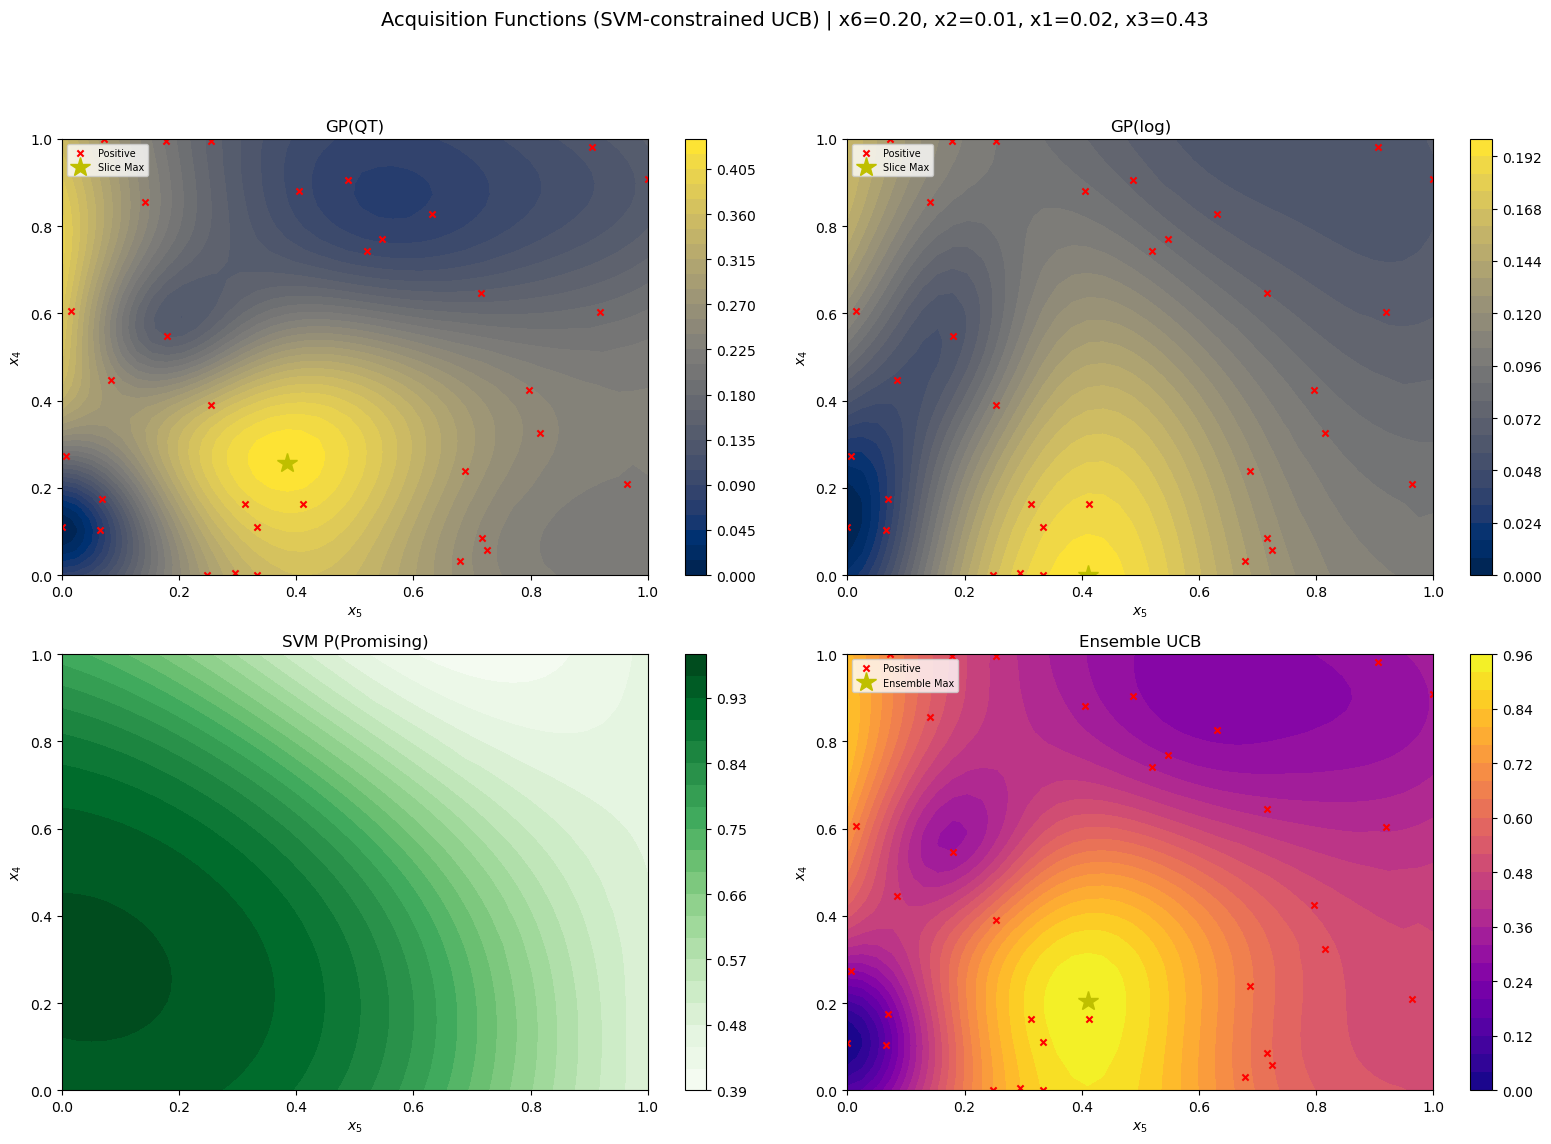

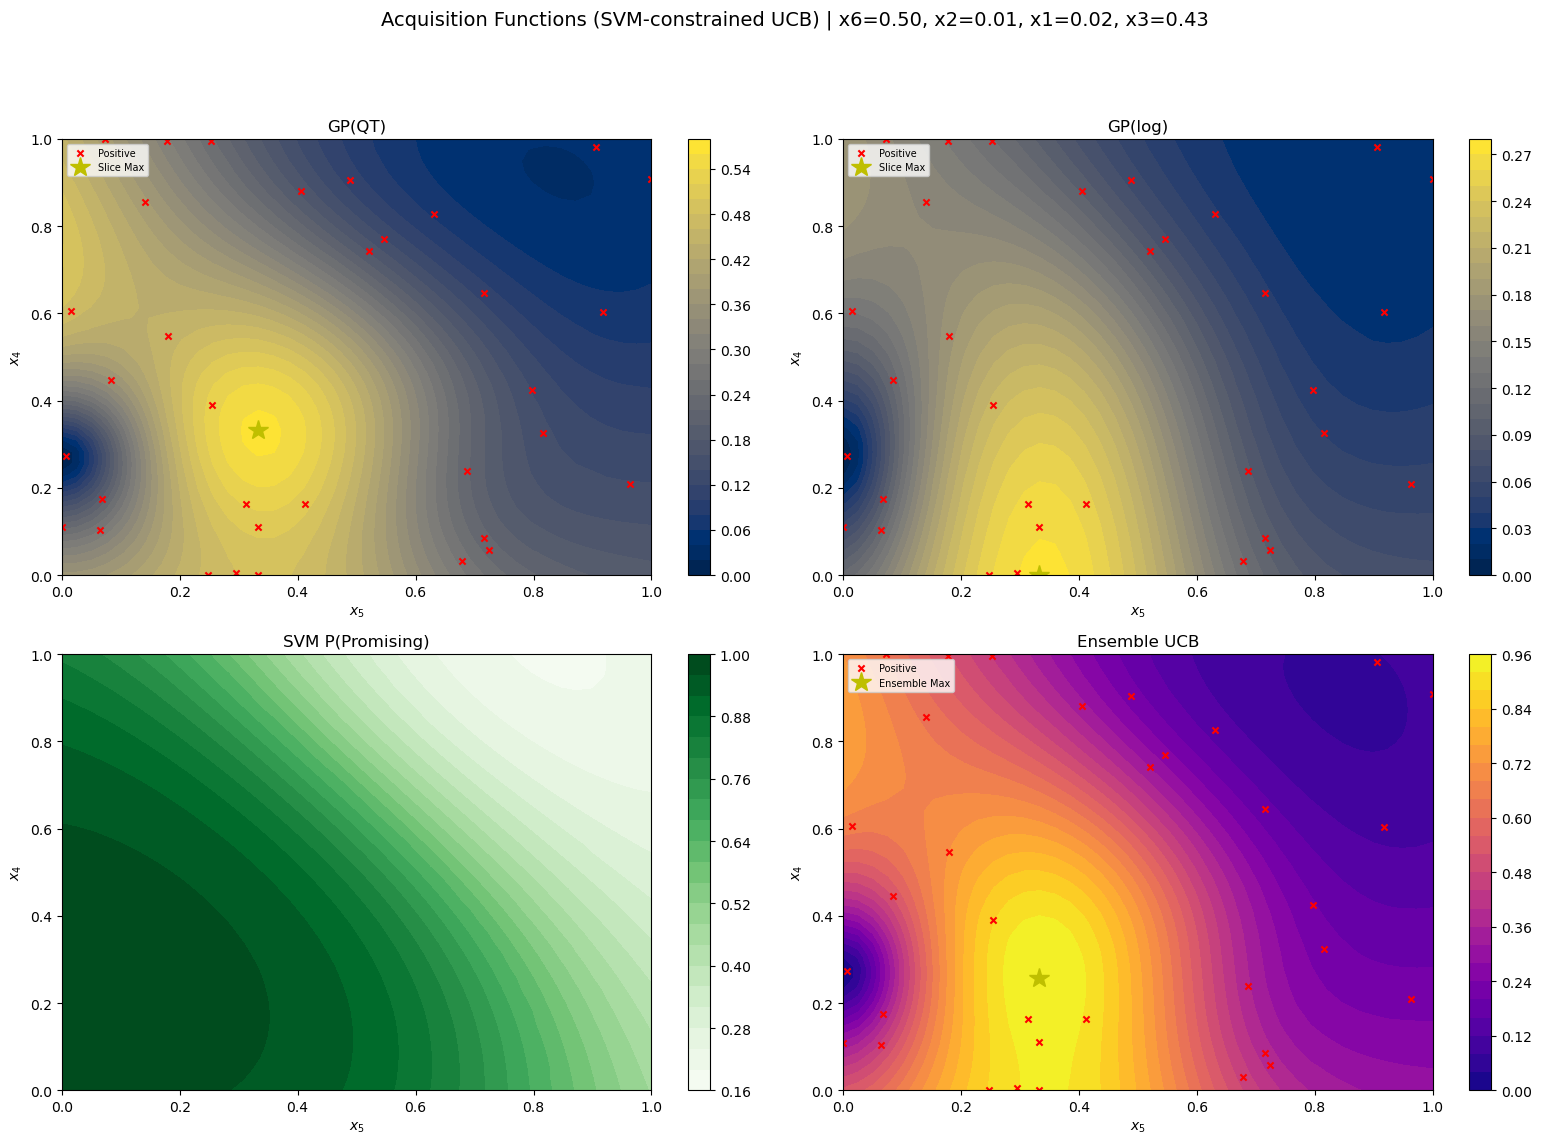

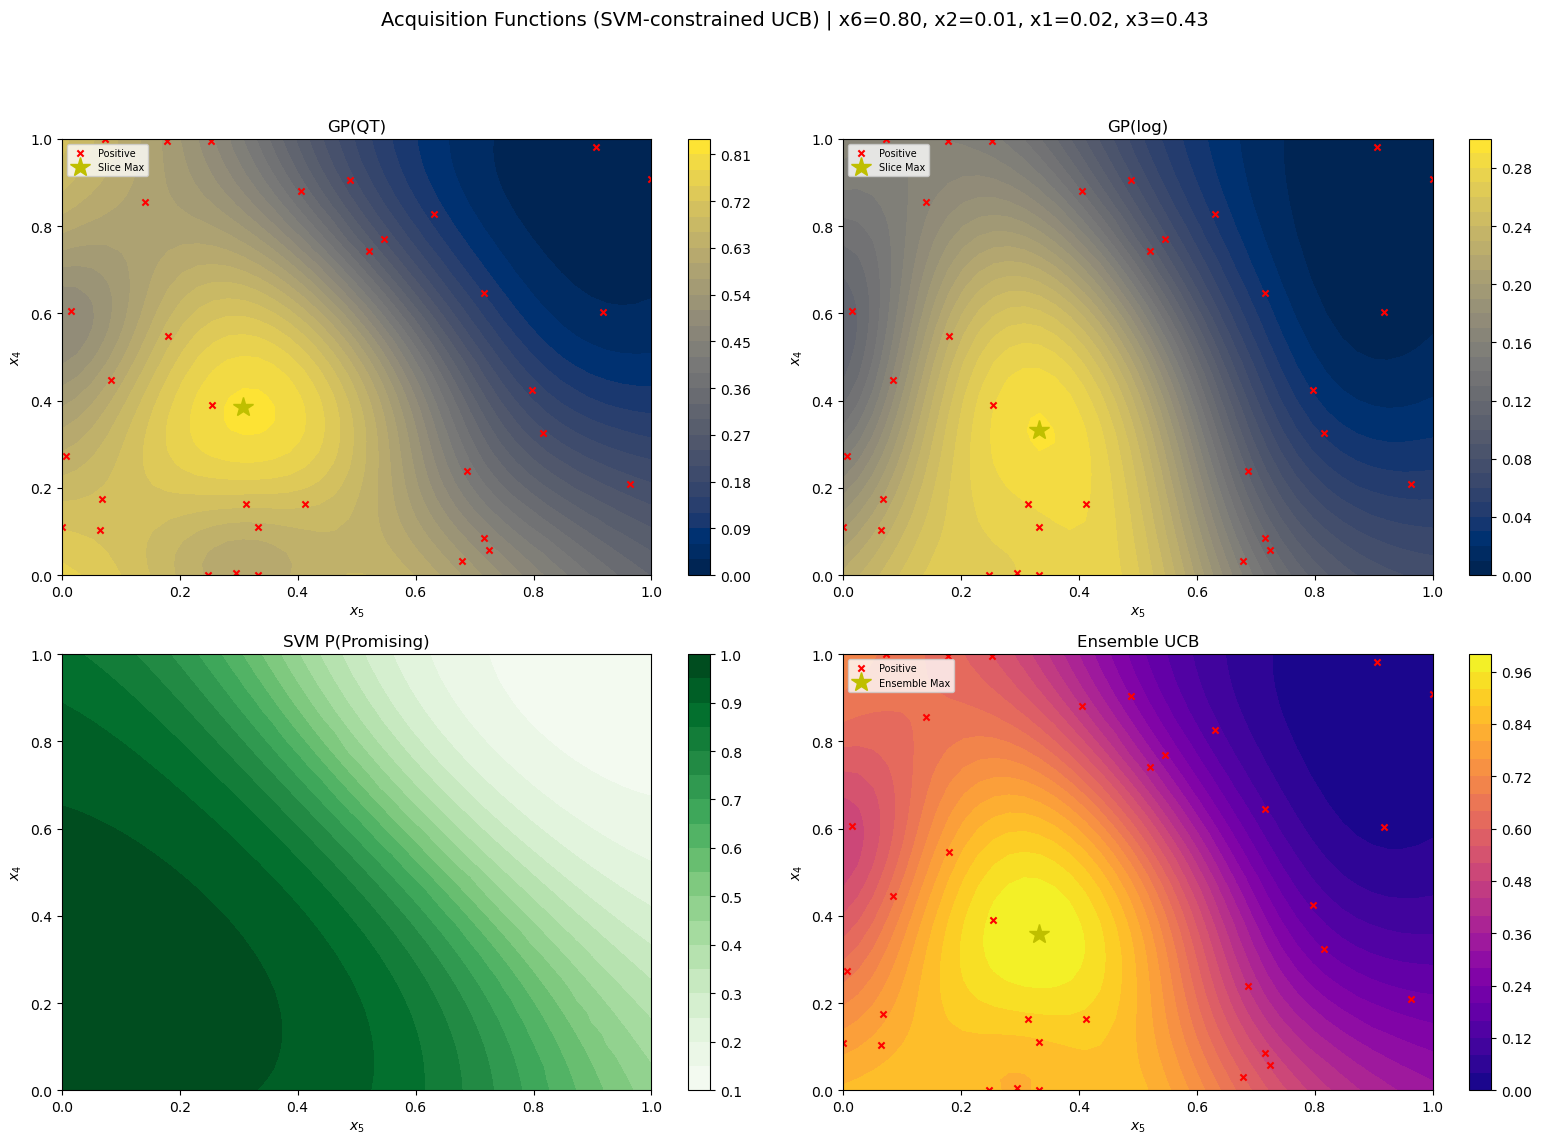

RECOMMENDED NEXT POINT (Ensemble of 2 GPs, 50K LHS in 5D active space)
  Input (original space): [0.072925 0.023401 0.400488 0.398386 0.295583 0.675599]
  SVM P(promising):       0.959

Individual surrogate suggestions:
    GP (y_qt)           : [0.671358 0.917328 0.400488 0.875802 0.846093 0.0571  ] (SVM P=0.948)
    GP (y_log)          : [0.072925 0.023401 0.400488 0.398386 0.295583 0.675599] (SVM P=0.959)

Sanity check - is this a corner?
  x1 = 0.0170 <-- BOUNDARY!
  x2 = 0.0127 <-- BOUNDARY!
  x3 = 0.4309 (noise dim, fixed at training mean)
  x4 = 0.3659 
  x5 = 0.2853 
  x6 = 0.6940 

Current best: [0.057896 0.316106 0.003635 0.172254 0.342847 0.751032] (y = 1.6140074893388323)

  SVM coverage: 46.7% promising (fail-safe threshold: 5%)
  SVM effective weights: SVM P(promising)


In [9]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    return mu + kappa * sigma

def constrained_ucb(ucb_vals, svm_proba):
    ucb_shifted = ucb_vals - ucb_vals.min() + 1e-6
    return ucb_shifted * svm_proba

def normalize_01(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

# x3 (index 2) has length_scale=100 in both GPs (0.1% importance) — noise dimension.
# Apply same noise-drop strategy as Fn8: search over 5D active subspace, fix x3 at mean.
noise_dim_idx = 2   # x3
active_dims_acq = [d for d in range(n_dims) if d != noise_dim_idx]
n_active_acq = len(active_dims_acq)
x3_fixed_val = X_train[:, noise_dim_idx].mean()
print(f"Noise dim: x3 (index {noise_dim_idx}), fixed at training mean = {x3_fixed_val:.4f}")
print(f"Active dims for LHS: {['x'+str(d+1) for d in active_dims_acq]}")

# Generate LHS in 5D active subspace (50K for coverage)
sampler = LatinHypercube(d=n_active_acq, seed=42)
X_cand_active = sampler.random(n=50_000)

# Reconstruct full 6D candidates with x3 fixed at training mean
X_candidates = np.zeros((50_000, n_dims))
for j, orig_dim in enumerate(active_dims_acq):
    X_candidates[:, orig_dim] = X_cand_active[:, j]
X_candidates[:, noise_dim_idx] = x3_fixed_val

# Budget-aware kappa: linear decay from 5.0 (week 1) to 2.0 (week 13)
WEEK = 5
kappa = 5.0 - ((WEEK - 1) / 13) * 3.0
print(f"kappa = {kappa:.4f} (week {WEEK}/13)")

# GP predictions on candidates (full 6D GPs, x3 fixed so it contributes nothing)
mu_gp_qt, sigma_gp_qt = gp_qt.predict(X_candidates, return_std=True)
mu_gp_log, sigma_gp_log = gp_log.predict(X_candidates, return_std=True)

# SVM probability
svm_proba = svm_clf.predict_proba(X_candidates)[:, 1]

# Fix A: SVM fail-safe — if SVM collapses to classify <5% of candidates as promising,
# fall back to uniform weights so the constraint doesn't silence the acquisition surface.
if (svm_proba > 0.5).mean() < 0.05:
    print("WARNING: SVM classified <5% of candidates as promising — applying fail-safe (uniform weights).")
    svm_proba_effective = np.ones_like(svm_proba)
else:
    svm_proba_effective = svm_proba

# UCB scores
ucb_gp_qt = upper_confidence_bound(mu_gp_qt, sigma_gp_qt, kappa=kappa)
ucb_gp_log = upper_confidence_bound(mu_gp_log, sigma_gp_log, kappa=kappa)

# Constrained UCBs
ucb_c_gp_qt = constrained_ucb(ucb_gp_qt, svm_proba_effective)
ucb_c_gp_log = constrained_ucb(ucb_gp_log, svm_proba_effective)

# Ensemble
ensemble_ucb = (normalize_01(ucb_c_gp_qt) + normalize_01(ucb_c_gp_log)) / 2.0

best_ensemble_idx = np.argmax(ensemble_ucb)
x_next_norm = X_candidates[best_ensemble_idx]  # full 6D, x3 fixed at mean
x_next_orig = scaler_X.inverse_transform([x_next_norm])[0]

# Per-surrogate bests
surrogates = {'GP (y_qt)': ucb_c_gp_qt, 'GP (y_log)': ucb_c_gp_log}
best_points = {}
for name, ucb_vals in surrogates.items():
    idx = np.argmax(ucb_vals)
    best_points[name] = {
        'idx': idx, 'norm': X_candidates[idx],
        'orig': scaler_X.inverse_transform([X_candidates[idx]])[0],
        'svm_p': svm_proba[idx]
    }

# acquisition slices
def plot_acq_slices(**kwargs):
    grid_nd = np.zeros((n_grid_2d * n_grid_2d, n_dims))
    grid_nd[:, dim_a] = X1_plot.ravel()
    grid_nd[:, dim_b] = X2_plot.ravel()
    for d in slider_dims:
        grid_nd[:, d] = kwargs[f'x{d+1}']
    
    fixed_parts = [f'x{d+1}={kwargs[f"x{d+1}"]:.2f}' for d in slider_dims]
    fixed_info = ', '.join(fixed_parts)
    
    mu_qt_s, sigma_qt_s = gp_qt.predict(grid_nd, return_std=True)
    mu_log_s, sigma_log_s = gp_log.predict(grid_nd, return_std=True)
    svm_p_s = svm_clf.predict_proba(grid_nd)[:, 1]
    
    ucb_qt_s = constrained_ucb(upper_confidence_bound(mu_qt_s, sigma_qt_s, kappa), svm_p_s)
    ucb_log_s = constrained_ucb(upper_confidence_bound(mu_log_s, sigma_log_s, kappa), svm_p_s)
    ens_s = (normalize_01(ucb_qt_s) + normalize_01(ucb_log_s)) / 2.0
    
    shape = (n_grid_2d, n_grid_2d)
    plot_nd_acquisition_comparison_slice(
        X1_plot, X2_plot,
        {'GP(QT)': ucb_qt_s.reshape(shape), 'GP(log)': ucb_log_s.reshape(shape)},
        svm_p_s.reshape(shape), ens_s.reshape(shape),
        X_train_pos, X_train_neg,
        dim1_idx=dim_a, dim2_idx=dim_b, fixed_info=fixed_info
    )

for v in [0.2, 0.5, 0.8]:
    kws = {f'x{d+1}': (v if d == slider_dims[0] else float(x_next_norm[d])) for d in slider_dims}
    plot_acq_slices(**kws)

# Summary
print(f"{'='*80}")
print(f"RECOMMENDED NEXT POINT (Ensemble of 2 GPs, 50K LHS in 5D active space)")
print(f"{'='*80}")
print(f"  Input (original space): {np.array_str(x_next_orig, precision=6)}")
print(f"  SVM P(promising):       {svm_proba[best_ensemble_idx]:.3f}")

print(f"\nIndividual surrogate suggestions:")
for name, bp in best_points.items():
    print(f"    {name:20s}: {np.array_str(bp['orig'], precision=6)} (SVM P={bp['svm_p']:.3f})")

print(f"\nSanity check - is this a corner?")
for i in range(n_dims):
    if i == noise_dim_idx:
        print(f"  x{i+1} = {x_next_norm[i]:.4f} (noise dim, fixed at training mean)")
    else:
        at_boundary = x_next_norm[i] < 0.02 or x_next_norm[i] > 0.98
        print(f"  x{i+1} = {x_next_norm[i]:.4f} {'<-- BOUNDARY!' if at_boundary else ''}")

print(f"\nCurrent best: {X_train_raw[np.argmax(y_train_raw)]} (y = {y_train_raw.max()})")
print(f"\n  SVM coverage: {(svm_proba > 0.5).mean()*100:.1f}% promising (fail-safe threshold: 5%)")
print(f"  SVM effective weights: {'uniform (fail-safe)' if (svm_proba > 0.5).mean() < 0.05 else 'SVM P(promising)'}")
